# S-PosteriorScatter

ABC-SMC posterior scatter matrix with split-axes summary bars on diagonal.

Each diagonal cell is split into a narrow strip (summary bar) and the histogram below.

Style matches NPI figures: light fill = 95% CI, darker fill = IQR, vertical line = median.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})
for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = font
        break
    except:
        pass

PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
SIM_DIR = PROJ_ROOT / 'analysis' / 'simulations'
FIG_DIR = FINAL_DIR / 'figures'

abc = pd.read_csv(SIM_DIR / 'outputs' / 'abc_final' / 'abc_accepted.csv')
print(f'Loaded {len(abc)} accepted particles')

param_cols = ['beta', 'alpha', 'gamma', 'mu_c', 'npi_factor', 'tmrca_offset']
param_labels = {
    'beta': r'$\beta$ (transmission)',
    'alpha': r'$\alpha$ (density scaling)',
    'gamma': r'$\gamma$ (premises scaling)',
    'mu_c': r'$\mu_c$ (recovery days)',
    'npi_factor': r'$f_{NPI}$ (NPI factor)',
    'tmrca_offset': r'$\Delta_{tMRCA}$ (offset days)',
}

Loaded 75 accepted particles


Saved S_PosteriorScatter_v3

Posterior summary:
  beta: median=0.0043, IQR=[0.0027, 0.0075], 95% CI=[0.0013, 0.0237]
  alpha: median=0.2722, IQR=[0.1127, 0.5043], 95% CI=[0.0285, 0.9361]
  gamma: median=0.4366, IQR=[0.2146, 0.6906], 95% CI=[0.0524, 0.9828]
  mu_c: median=28.0000, IQR=[16.0000, 43.0000], 95% CI=[7.0000, 57.1500]
  npi_factor: median=0.1850, IQR=[0.0645, 0.5126], 95% CI=[0.0034, 0.9313]
  tmrca_offset: median=91.0000, IQR=[84.0000, 110.5000], 95% CI=[80.0000, 133.3000]


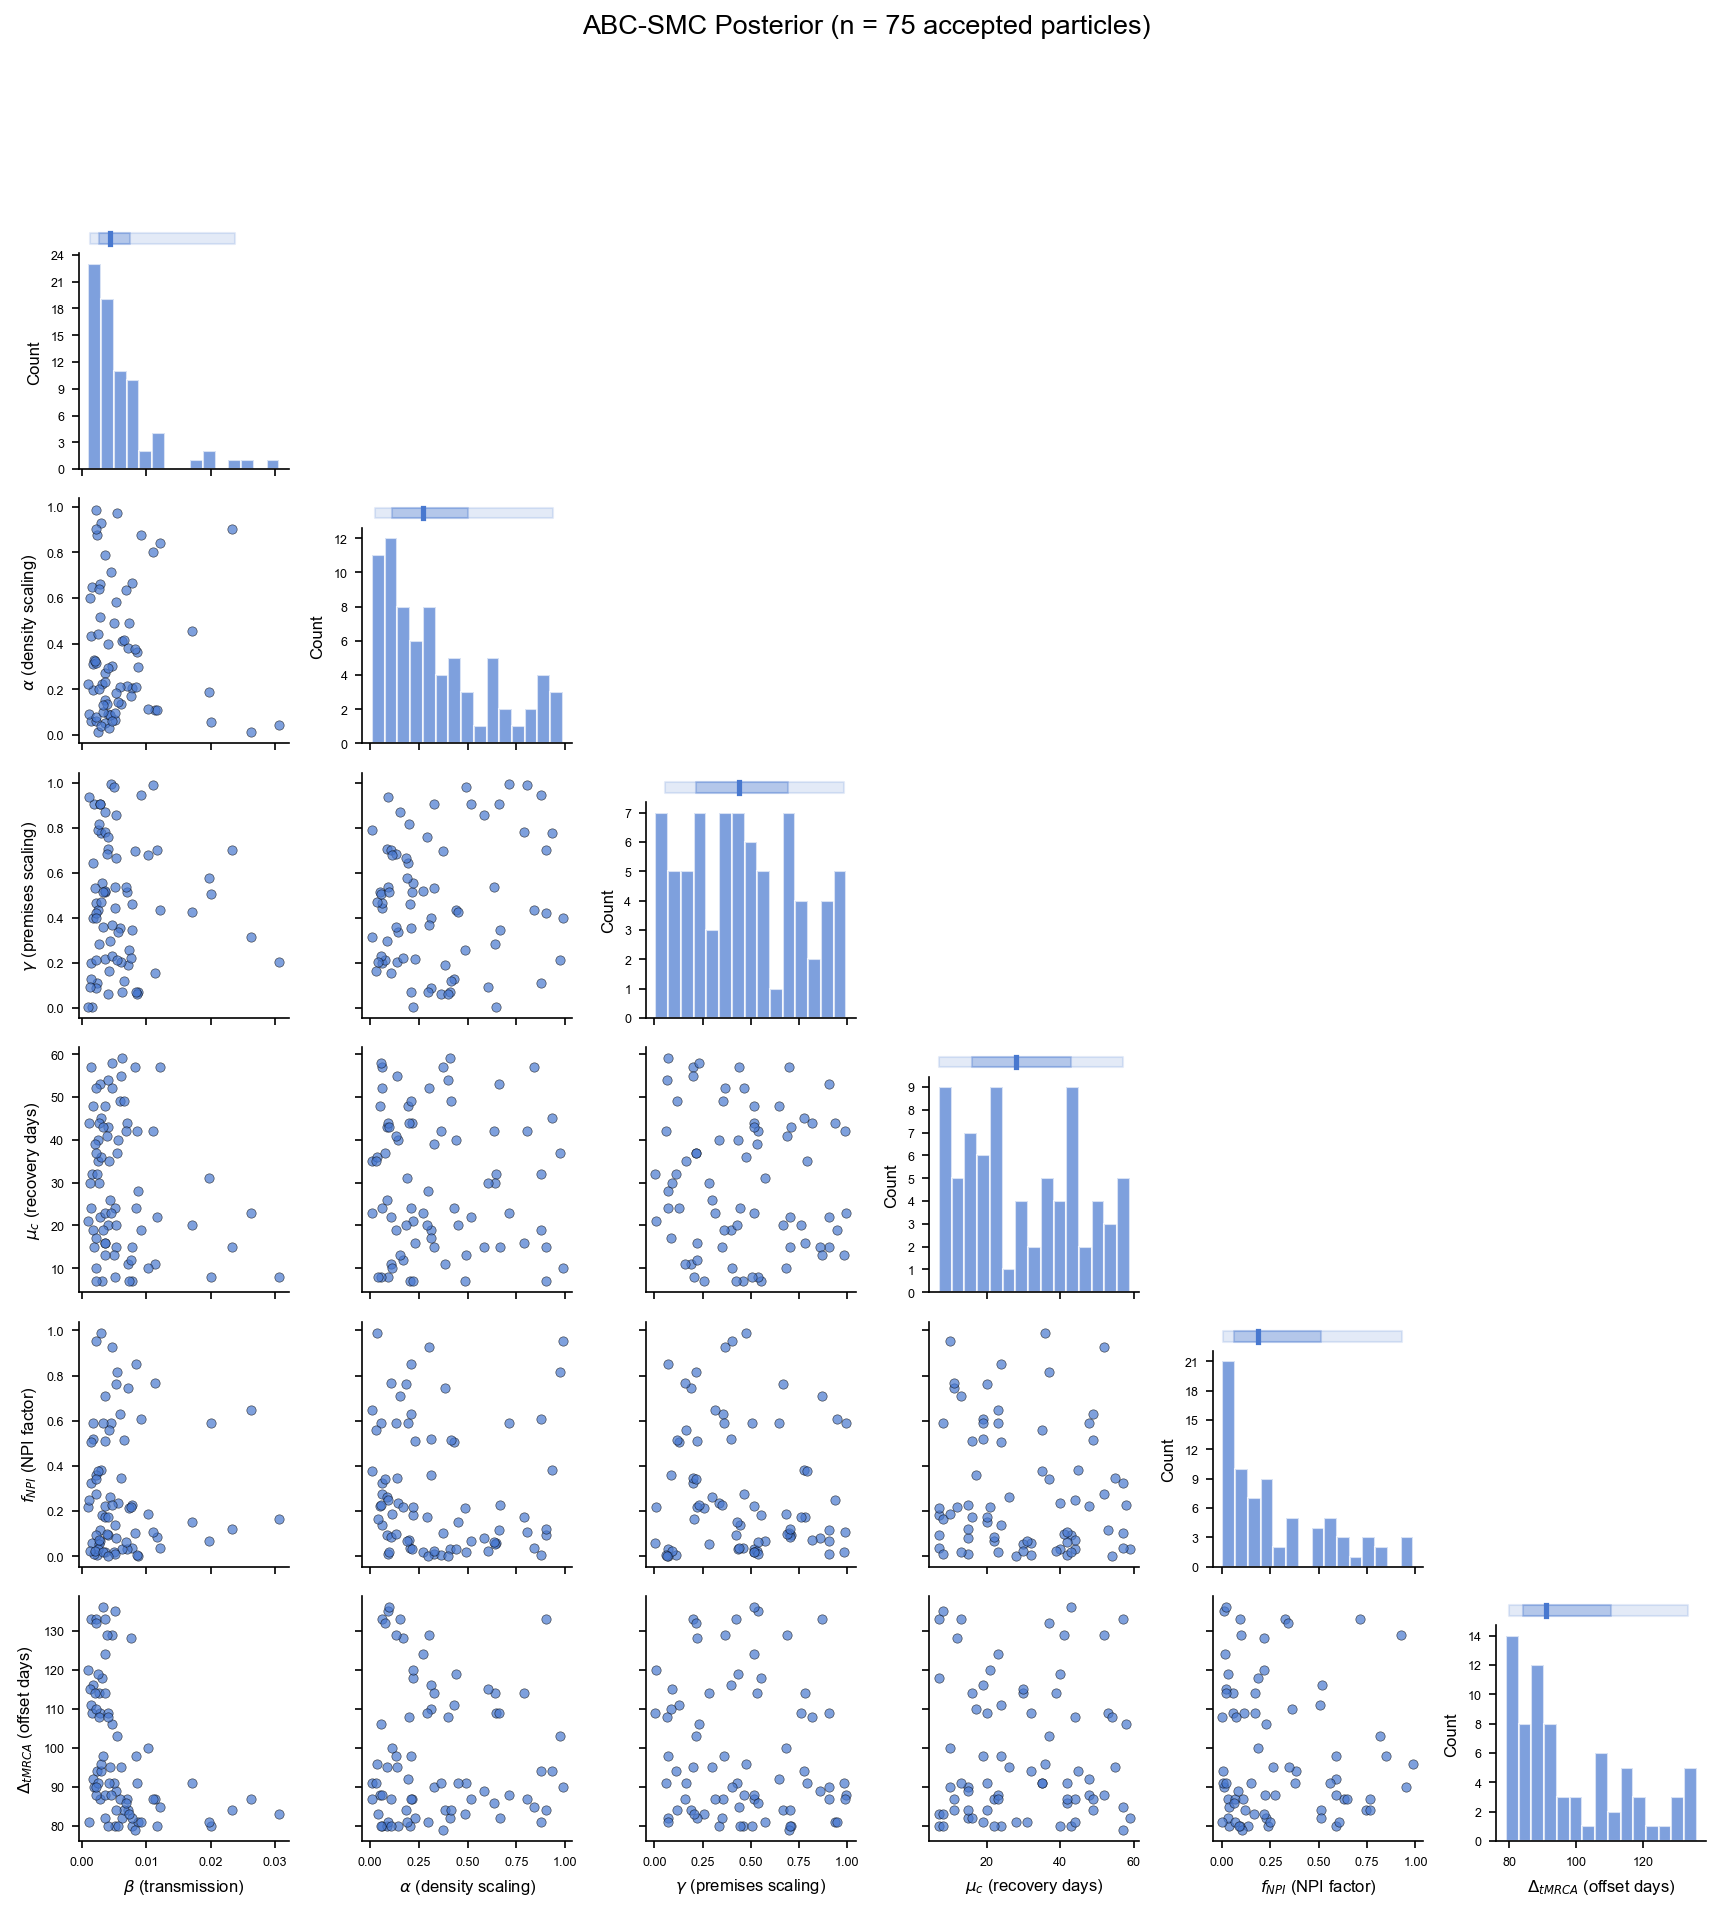

In [ ]:
COLOR = '#4878CF'
n = len(param_cols)
BAR_RATIO = 0.12  # fraction of cell height for summary bar

fig = plt.figure(figsize=(14, 14))
outer_gs = fig.add_gridspec(n, n, hspace=0.12, wspace=0.35)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Store scatter/hist axes for axis sharing and labeling
main_axes = [[None]*n for _ in range(n)]

for i, pi in enumerate(param_cols):
    for j, pj in enumerate(param_cols):
        if i == j:
            # Split into summary bar (top) + histogram (bottom)
            inner_gs = outer_gs[i, j].subgridspec(2, 1,
                height_ratios=[BAR_RATIO, 1 - BAR_RATIO], hspace=0.0)
            ax_bar = fig.add_subplot(inner_gs[0])
            ax_hist = fig.add_subplot(inner_gs[1])
            main_axes[i][j] = ax_hist

            vals = abc[pi].values
            q025, q25, med, q75, q975 = np.percentile(vals, [2.5, 25, 50, 75, 97.5])

            # Histogram
            ax_hist.hist(vals, bins=15, color=COLOR, alpha=0.7, edgecolor='white')
            ax_hist.yaxis.set_major_locator(MaxNLocator(integer=True))
            style_ax(ax_hist)

            # Summary bar
            bar_height = 0.18
            ax_bar.fill_between([q025, q975], 0.5 - bar_height, 0.5 + bar_height,
                                color=COLOR, alpha=0.15)
            ax_bar.fill_between([q25, q75], 0.5 - bar_height, 0.5 + bar_height,
                                color=COLOR, alpha=0.30)
            ax_bar.plot([med, med], [0.5 - bar_height, 0.5 + bar_height],
                        color=COLOR, lw=2.5)

            # Match x-limits to histogram
            ax_bar.set_xlim(ax_hist.get_xlim())
            ax_bar.set_ylim(0, 1)
            ax_bar.set_xticks([])
            ax_bar.set_yticks([])
            for spine in ax_bar.spines.values():
                spine.set_visible(False)

            # Labels
            ax_hist.set_ylabel('Count', fontsize=8)
            if i == n - 1:
                ax_hist.set_xlabel(param_labels[pj], fontsize=8)
            else:
                ax_hist.set_xticklabels([])
            ax_hist.tick_params(labelsize=6)

        elif i > j:
            ax = fig.add_subplot(outer_gs[i, j])
            main_axes[i][j] = ax
            ax.scatter(abc[pj], abc[pi], s=20, c=COLOR,
                       edgecolors='black', linewidths=0.3, alpha=0.7)
            style_ax(ax)

            if j == 0:
                ax.set_ylabel(param_labels[pi], fontsize=8)
            else:
                ax.set_yticklabels([])
            if i == n - 1:
                ax.set_xlabel(param_labels[pj], fontsize=8)
            else:
                ax.set_xticklabels([])
            ax.tick_params(labelsize=6)
        else:
            # Upper triangle — invisible
            ax = fig.add_subplot(outer_gs[i, j])
            ax.set_visible(False)

fig.suptitle(f'ABC-SMC Posterior (n = {len(abc)} accepted particles)', fontsize=13, y=0.98)
fig.savefig(FIG_DIR / 'S_PosteriorScatter.png')
fig.savefig(FIG_DIR / 'S_PosteriorScatter.pdf')
print('Saved S_PosteriorScatter')

print('\nPosterior summary:')
for p in param_cols:
    v = abc[p].values
    q025, q25, med, q75, q975 = np.percentile(v, [2.5, 25, 50, 75, 97.5])
    print(f'  {p}: median={med:.4f}, IQR=[{q25:.4f}, {q75:.4f}], 95% CI=[{q025:.4f}, {q975:.4f}]')

plt.show()